In [50]:
import pandas as pd
import os
import numpy as np
from pipeline_build_demand import run_pipeline
import matplotlib.pyplot as plt

# ELEC

In [4]:
baseline_path = "final_predictions/daily_baselines/baseline_no_month_elec_regions.csv"
temp_path = "base_data/temp_pecd/temp_FR_daily_pecd.csv"
temp_path_ERA = "base_data/temp_era/temp_FR_daily_era.csv"
thermo_coeffs_path = "final_predictions/thresholds_and_rates/elec_thermo_parameters_no_month.csv"

profiles_dir = "final_predictions/hourly_profiles"

In [51]:
coeffs = pd.read_csv(thermo_coeffs_path, index_col = 0)
temp = pd.read_csv(temp_path, index_col = 0, parse_dates = True)
temp_ERA = pd.read_csv(temp_path_ERA, index_col = 0, parse_dates = True)

Th = temp.copy()
r = "Normandie"

c = coeffs["heating_threshold"].loc["Normandie"]
Th[r] = temp[r].ewm(alpha=0.4, adjust=False).mean()

np.maximum(0, c - Th[r])
temp_ERA.mean()

Île-de-France                 11.962213
Centre-Val de Loire           12.403045
Bourgogne-Franche-Comté       11.528342
Normandie                     11.497184
Hauts-de-France               11.296880
Grand Est                     11.050798
Pays de la Loire              12.566828
Bretagne                      12.051501
Nouvelle-Aquitaine            13.465893
Occitanie                     12.734136
Auvergne-Rhône-Alpes          10.267189
Provence-Alpes-Côte d'Azur    11.520924
dtype: float64

In [3]:
hourly_demand, yearly_thermo = run_pipeline(baseline_path, temp_path, 
                                            thermo_coeffs_path, 
                                            profiles_dir, 
                                            conv_heating_2050=0.56, conv_cooling_2050=1, 
                                            alpha_hdd=0.4, alpha_cdd=0.6)

-----------------------------
Zones considérées:
Index(['Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne',
       'Centre-Val de Loire', 'Grand Est', 'Hauts-de-France', 'Normandie',
       'Nouvelle-Aquitaine', 'Occitanie', 'Pays de la Loire',
       'Provence-Alpes-Côte d'Azur', 'Île-de-France'],
      dtype='object')
-----------------------------
Years considered : 2040 to 2060
------------------------------------------------
Baseline constructed for the years considered
------------------------------------------------
Hourly demand constructed


In [4]:
total_demand = hourly_demand.sum(axis = 1)

In [5]:
total_demand.sum()/21/1e6

488.27095625550146

<Axes: >

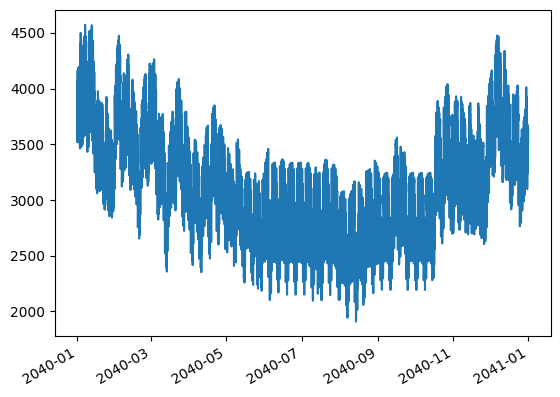

In [25]:
hourly_demand["Normandie"].loc["2040"].plot()

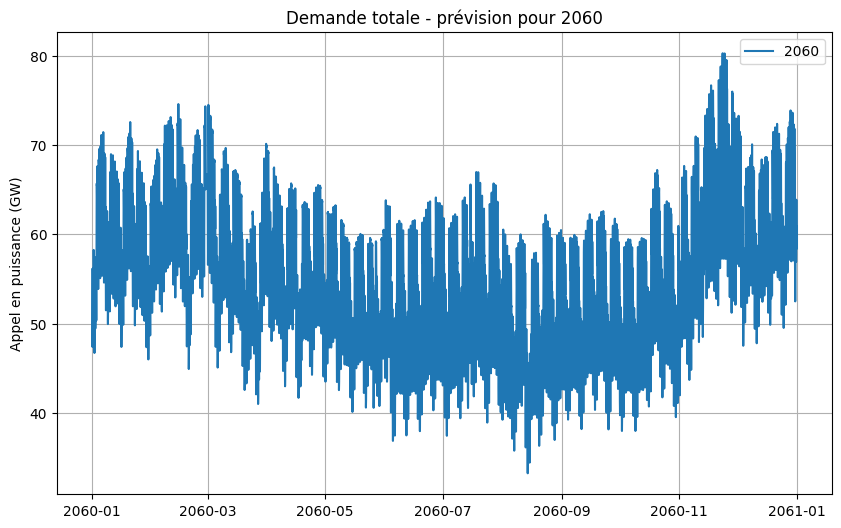

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))
plt.plot(total_demand.loc["2060"]/1000, label = '2060')
# plt.plot(total_demand.loc["2050"], label = '2050')
# plt.plot(total_demand.loc["2060"], label = '2060')
plt.legend()
plt.grid()
plt.ylabel("Appel en puissance (GW)")
plt.title("Demande totale - prévision pour 2060")
plt.show()

In [21]:
yearly_thermo["Auvergne-Rhône-Alpes"]["heating"]*24/1e6

year
2040    10.569114
2041    10.624859
2042     9.570674
2043    12.792112
2044     9.730190
2045     9.503824
2046     9.859921
2047    10.298465
2048     8.421091
2049    10.282591
2050    10.498386
2051    10.569046
2052    10.484262
2053    11.571411
2054     9.907711
2055     8.765090
2056    11.188018
2057    10.205857
2058     9.135058
2059    11.595883
2060    10.450519
Name: heating, dtype: float64

In [7]:
heating_demand = (yearly_thermo.xs("heating", axis=1, level=1).sum(axis=1)/1e6*24 )
cooling_demand = (yearly_thermo.xs("cooling", axis=1, level=1).sum(axis=1)/1e6*24)
print(f"Cooling demand: {cooling_demand}")
print(f"Heating demand: {heating_demand}")

Cooling demand: year
2040    4.787223
2041    1.583767
2042    6.078132
2043    1.986819
2044    6.072107
2045    3.241896
2046    2.401949
2047    1.480444
2048    5.060310
2049    4.264182
2050    4.693722
2051    2.206630
2052    6.142729
2053    2.305498
2054    2.817732
2055    3.557306
2056    5.835363
2057    4.706062
2058    4.562842
2059    3.606494
2060    5.606536
dtype: float64
Heating demand: year
2040    47.061050
2041    43.349276
2042    41.001617
2043    54.922278
2044    41.163099
2045    43.072335
2046    43.442228
2047    44.144877
2048    36.511300
2049    41.499093
2050    45.852903
2051    44.944750
2052    44.671281
2053    50.674907
2054    42.295720
2055    38.510792
2056    47.076109
2057    44.503034
2058    39.676332
2059    51.654339
2060    44.665019
dtype: float64


In [10]:
heating_demand = (yearly_thermo.xs("heating", axis=1, level=1).sum(axis=1)/1e6*24 ).mean()
cooling_demand = (yearly_thermo.xs("cooling", axis=1, level=1).sum(axis=1)/1e6*24).mean()
print(f"Avec les données utilisées:")
print(f"Cooling demand: {cooling_demand:.2f} TWh/an")
print(f"Heating demand: {heating_demand:.2f} TWh/an")

Avec les données utilisées:
Cooling demand: 3.95 TWh/an
Heating demand: 44.32 TWh/an


In [11]:
total_demand_FR = total_demand.copy()
total_demand_FR.sum()/21/1e6

488.27095625550146

# GAS

In [2]:
baseline_path = "final_predictions/daily_baselines/baseline_no_month_gas_regions.csv"
temp_path = "base_data/temp_pecd/temp_FR_daily_pecd.csv"
temp_path_ERA = "base_data/temp_era/temp_FR_daily_era.csv"
thermo_coeffs_path = "final_predictions/thresholds_and_rates/gas_thermo_parameters_no_month.csv"

profiles_dir = "final_predictions/hourly_profiles"

In [3]:
hourly_demand, yearly_thermo = run_pipeline(baseline_path, temp_path, thermo_coeffs_path, profiles_dir, vector = "gas", alpha_hdd = 0.4)

-----------------------------
Zones considérées:
Index(['Île-de-France', 'Centre-Val de Loire', 'Bourgogne-Franche-Comté',
       'Normandie', 'Hauts-de-France', 'Grand Est', 'Pays de la Loire',
       'Bretagne', 'Nouvelle-Aquitaine', 'Occitanie', 'Auvergne-Rhône-Alpes',
       'Provence-Alpes-Côte d'Azur'],
      dtype='object')
-----------------------------
Years considered : 2040 to 2060
------------------------------------------------
Baseline constructed for the years considered
------------------------------------------------
Hourly demand constructed


In [4]:
heating_demand = (yearly_thermo.xs("heating", axis=1, level=1).sum(axis=1)/1e6*24 ).mean()
print(f"Avec les données utilisées:")
print(f"Heating demand: {heating_demand:.2f} TWh/an")

Avec les données utilisées:
Heating demand: 28.23 TWh/an


In [8]:
hourly_demand.sum().sum()/1e6/21

139.22806861858905

In [9]:
baseline = pd.read_csv(baseline_path, index_col = 0, parse_dates = True)

In [10]:
hourly_demand_FR = hourly_demand.sum(axis=1) / 1e3
hourly_demand_FR.sum()/1e3/21

139.22806861858902

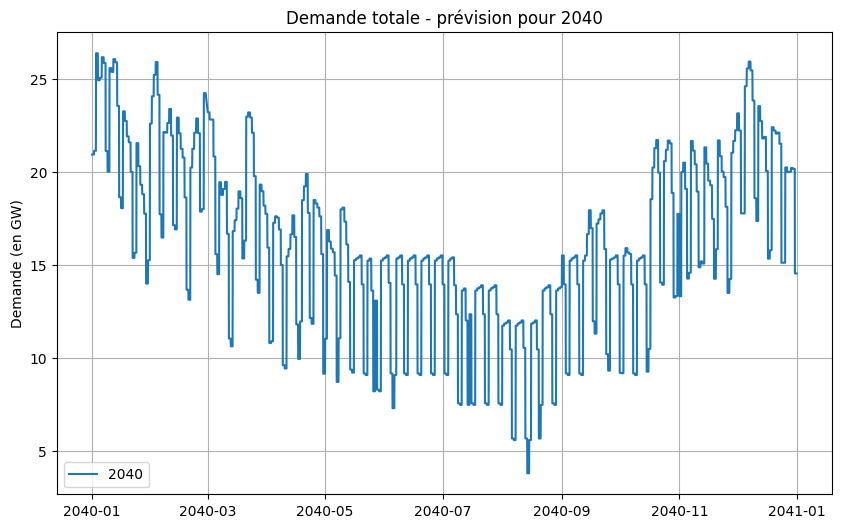

In [17]:
plt.figure(figsize = (10,6))
plt.plot(hourly_demand_FR.loc["2040"], label = '2040')
# plt.plot(total_demand.loc["2050"], label = '2050')
# plt.plot(total_demand.loc["2060"], label = '2060')
plt.legend()
plt.grid()
plt.ylabel("Demande (en GW)")
plt.title("Demande totale - prévision pour 2040")
plt.show()

On ajoute les pays frontaliers

In [18]:
ch4_demand_EU = {"DE": 102, "UK":80, "IT":97, "ES":84, "CH":7, "BE":38}

In [21]:
ch4_demand = hourly_demand_FR.rename("FR").to_frame()
for key, value in ch4_demand_EU.items():
    ch4_demand[key] = value/8.760
ch4_demand["FR"].sum()/21/1e3

139.22806861858902

In [22]:
ch4_demand.to_csv("final_hourly_demand_gas_EU.csv")

# EU COUNTRIES

In [12]:
from pipeline_build_demand_EU import run_pipeline

In [13]:
baseline_path = "final_predictions/daily_baselines/baseline_noT_EU.csv"
temp_path = "base_data/temp_pecd/temp_EU_daily_pecd.csv"
temp_path_ERA = "base_data/temp_era/temp_EU_daily_ERA.csv"
thermo_coeffs_path = "final_predictions/thresholds_and_rates/elec_thermo_parameters_EU.csv"

profiles_dir = "final_predictions/hourly_profiles/EU"

In [14]:
hourly_demand, yearly_thermo = run_pipeline(baseline_path, temp_path, thermo_coeffs_path, profiles_dir)

-----------------------------
Zones considerees:
Index(['BE', 'CH', 'DE', 'ES', 'IT', 'UK'], dtype='object')
-----------------------------
Years considered : 2015 to 2065
------------------------------------------------
Baseline constructed for the years considered
------------------------------------------------
Hourly demand constructed


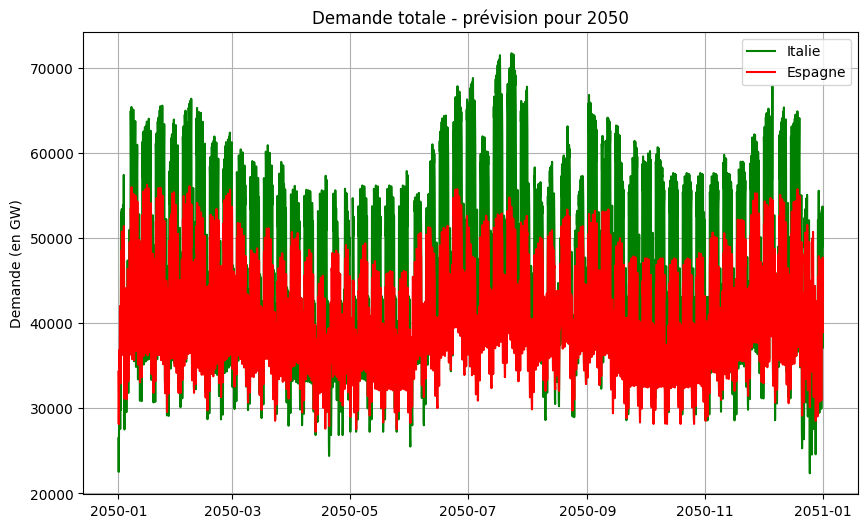

In [27]:
plt.figure(figsize = (10,6))
plt.plot(hourly_demand["IT"].loc["2050"], label = 'Italie', color = "green")
plt.plot(hourly_demand["ES"].loc["2050"], label = 'Espagne', color = "red")
# plt.plot(total_demand.loc["2050"], label = '2050')
# plt.plot(total_demand.loc["2060"], label = '2060')
plt.legend()
plt.grid()
plt.ylabel("Demande (en GW)")
plt.title("Demande totale - prévision pour 2050")
plt.show()

In [5]:
(yearly_thermo.xs("heating", axis=1, level=1)/1e6*24 + yearly_thermo.xs("cooling", axis=1, level=1)/1e6*24).mean()

BE     4.930157
CH     5.018288
DE    24.117264
ES    23.895496
IT    27.601658
UK    29.190616
dtype: float64

In [15]:
hourly_demand = hourly_demand[(hourly_demand.index >= "2040") & (hourly_demand.index < "2061")]

In [7]:
hourly_demand.to_csv("final_hourly_demand_EU.csv")

In [14]:
tot = hourly_demand.sum()/1e6/21

In [15]:
tot.sum()

505.3043639220125

In [16]:
hourly_demand_EU = hourly_demand.copy()

In [17]:
hourly_demand_EU["FR"] = total_demand_FR

In [22]:
hourly_demand_EU.loc["2052"].sum()/1e6

BE    119.809949
CH     74.923398
DE    683.752849
ES    365.425395
IT    411.111239
UK    567.830354
FR    491.037467
dtype: float64

In [23]:
hourly_demand_EU = hourly_demand_EU/1e3
hourly_demand_EU.to_csv("final_hourly_demand_EU.csv")

Analyse températures élevées

In [11]:
demand = pd.read_csv("final_hourly_demand_EU.csv", index_col = 0, parse_dates = True)

Juillet 2040 52.51849812982501
Aout 2040 50.45017808236672
Juillet 2041 50.87877512135686
Aout 2041 48.60786198086478
Juillet 2042 54.14675921134139
Aout 2042 48.96437482176706
Juillet 2043 52.129521022763704
Aout 2043 48.007884625007705
Juillet 2044 52.93208380479463
Aout 2044 50.633733662582024
Juillet 2045 51.26354445153847
Aout 2045 50.01948165363159
Juillet 2046 51.511146571467755
Aout 2046 48.564592978327624
Juillet 2047 50.900839348227784
Aout 2047 48.44513895512819
Juillet 2048 52.327520712013914
Aout 2048 50.312784757368085
Juillet 2049 51.61198885629658
Aout 2049 50.028660980667105
Juillet 2050 52.35916979438906
Aout 2050 49.97720560500598
Juillet 2051 51.176012621765175
Aout 2051 49.16881039668692
Juillet 2052 54.245906088194594
Aout 2052 49.77168124497437
Juillet 2053 50.70742599961387
Aout 2053 49.27840503270621
Juillet 2054 52.51191851704431
Aout 2054 49.004817524993214
Juillet 2055 52.966373436562286
Aout 2055 48.857002236635964
Juillet 2056 52.678120948299544
Aout 2056 

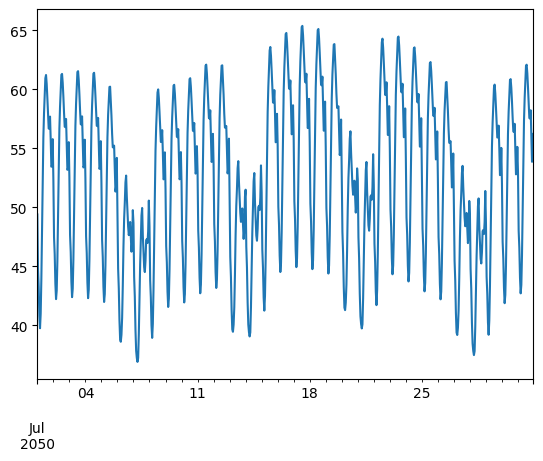

In [20]:
fr_demand = demand["FR"].loc["07-2050"]
fr_demand.plot()
for y in range(2040,2061):
    fr_demand = demand["FR"].loc[f"07-{y}"]
    print(f"Juillet {y}",fr_demand.mean())
    fr_demand = demand["FR"].loc[f"08-{y}"]
    print(f"Aout {y}",fr_demand.mean())

2048 et 2057  2052

<Axes: >

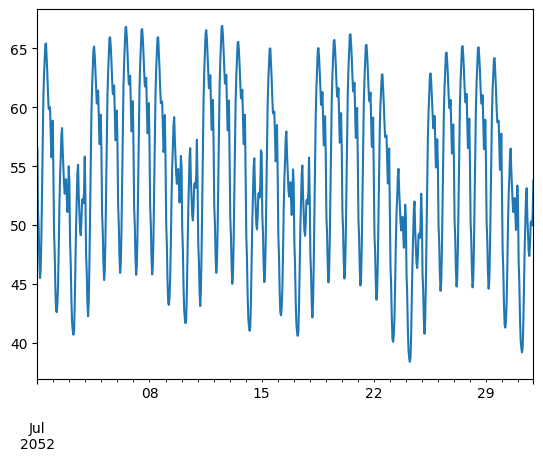

In [23]:
fr_demand = demand["FR"].loc["07-2052"]
fr_demand.plot()

In [49]:
import pandas as pd
import numpy as np

# ----------------------- Paramètres à ajuster -----------------------
CSV_PATH    = "base_data/temp_pecd/temp_FR_daily_pecd.csv"   # chemin vers ton fichier
PCTL        = 95                   # percentile-seuil : 90 (large) ou 95 (sévère)
WINDOW      = 15                   # demi-fenêtre calendaire (±15 j) pour un seuil saisonnier
MIN_DUREE   = 5                   # nb de jours consécutifs minimum pour une canicule
MOIS_CHAUDS = range(5, 10)         # détection restreinte à mai–sept. (range(1,13) = toute l'année)

# ----------------------- Chargement -----------------------
df = pd.read_csv(CSV_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
regions = [c for c in df.columns if c != "Date"]
doy  = df["Date"].dt.dayofyear.to_numpy()
mois = df["Date"].dt.month.to_numpy()

# --- Seuil = percentile glissant par jour calendaire, région par région ---
# (le seuil s'adapte à la saison : le 95e percentile de juillet n'est pas celui de mars)
def seuils_glissants(serie):
    vals = serie.to_numpy(dtype=float)
    table = np.empty(367)
    for d in range(1, 367):
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 366 - dist)          # fenêtre circulaire (gère déc/janv)
        table[d] = np.nanpercentile(vals[dist <= WINDOW], PCTL)
    return table[doy]

# ----------------------- Détection des épisodes -----------------------
episodes = []
for reg in regions:
    seuil = seuils_glissants(df[reg])
    chaud = (df[reg].to_numpy() > seuil) & np.isin(mois, list(MOIS_CHAUDS))
    grp = (~chaud).cumsum()                          # identifie les blocs de jours chauds consécutifs
    for _, idx in pd.Series(np.arange(len(df))[chaud]).groupby(grp[chaud]):
        i0, i1 = idx.iloc[0], idx.iloc[-1]
        duree = i1 - i0 + 1
        if duree >= MIN_DUREE:
            temps = df[reg].to_numpy()[i0:i1+1]
            episodes.append({
                "region": reg,
                "debut": df["Date"].iloc[i0].date(),
                "fin":   df["Date"].iloc[i1].date(),
                "duree_jours": int(duree),
                "temp_pic": round(float(temps.max()), 1),
                "depassement_moyen": round(float((temps - seuil[i0:i1+1]).mean()), 1),
                "annee": int(df["Date"].iloc[i0].year),
                "semaine_iso": int(df["Date"].iloc[i0].isocalendar().week),
            })

episodes = pd.DataFrame(episodes).sort_values(["debut", "region"]).reset_index(drop=True)
print(f"{len(episodes)} épisodes de canicule détectés")
episodes[episodes.annee == 2044]

88 épisodes de canicule détectés


,region,debut,fin,duree_jours,temp_pic,depassement_moyen,annee,semaine_iso
4,Normandie,2044-05-08,2044-05-16,9,24.4,2.4,2044,18
5,Pays de la Loire,2044-05-08,2044-05-16,9,25.2,1.4,2044,18
6,Centre-Val de Loire,2044-05-09,2044-05-16,8,26.1,1.8,2044,19
7,Hauts-de-France,2044-05-09,2044-05-16,8,24.8,3.1,2044,19
8,Île-de-France,2044-05-09,2044-05-16,8,25.9,2.6,2044,19
9,Grand Est,2044-05-10,2044-05-16,7,25.0,2.3,2044,19
10,Bourgogne-Franche-Comté,2044-05-11,2044-05-16,6,24.5,1.6,2044,19
11,Bretagne,2044-05-11,2044-05-15,5,22.8,2.1,2044,19
12,Auvergne-Rhône-Alpes,2044-05-12,2044-05-16,5,22.6,1.9,2044,19
13,Hauts-de-France,2044-07-12,2044-07-18,7,29.7,1.7,2044,28
